In [ ]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
r = np.full((20, 1000),fill_value=np.nan)

In [ ]:
df = pd.read_csv('ratings_long.csv')

In [ ]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [ ]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

In [ ]:
import numpy as np
import pandas as pd

# gozlemlenen (NaN olmayan) indisleri bul
obs_rows, obs_cols = np.where(~np.isnan(r))

train_mask = np.zeros(r.shape, dtype=bool)
train_mask[obs_rows, obs_cols] = True

print(f'Toplam gozlem : {train_mask.sum()}')



Toplam gozlem : 200


$min_{u,v} {\frac{1}{|\Omega|}{\sum_{(i,j) \in \Omega}{ (r_{ij} - (uv)_{ij})^2}}} + \lambda (\|u\|_F^2 + \|v\|_F^2)$

- $\Omega$ : gozlemlenen (NaN olmayan) indisler kumesi
- $\lambda$ : L2 regularizasyon katsayisi -- overfitting'i onler

In [ ]:
# loss_fn:  np.mean((y_true - y_pred)**2)
def loss_fn_mf(r_obs, pred, mask):
    residual = mask * (r_obs - pred)
    N        = mask.sum()
    return np.sum(residual ** 2) / N


L2 secme sebebi: gradyan her noktada turevlenebilir, L1'in 0'daki sorununu ortadan kaldirir

### Matrix Factorization

Kullanıcı-film puan matrisi, kullanıcı (`U`) ve film (`V`) latent özellik matrislerine ayrıştırılır. Model, `R ≈ U × V` olacak şekilde Gradient Descent ile eğitilir. L2 Regularization kullanılarak overfitting azaltılır ve eğitim verisindeki gözlemler (`train_mask`) üzerinden öğrenme gerçekleştirilir.

In [ ]:
def matrix_factorization_l2(r, train_mask, k=4, n_epoch=500, lr=0.05, lamb=0.01, init_scale=0.3, early_stop=True):
    n_users, n_movies = r.shape


    u = np.random.random((n_users, k)) * init_scale
    v = np.random.random((k, n_movies)) * init_scale

    r_obs = np.where(train_mask, r, 0)
    N     = train_mask.sum()

    g_u = np.zeros_like(u)
    g_v = np.zeros_like(v)

    loss_history = []

    for i in range(n_epoch):

        pred     = np.dot(u, v)
        residual = train_mask * (r_obs - pred)

        #  l2_reg
        g_u = -(2.0 / N) * np.dot(residual, v.T) + 2 * lamb * u  # (20 x 4)
        g_v = -(2.0 / N) * np.dot(u.T, residual) + 2 * lamb * v  # (4 x 1000)

        grad_norm = np.linalg.norm(g_u) + np.linalg.norm(g_v)
        loss      = loss_fn_mf(r_obs, pred, train_mask)
        loss_history.append(loss)

        print(f"Gradient norm epoch {i} {grad_norm:.6f} {loss:.4f}")


        if grad_norm < 0.01 and early_stop:
            break

        u -= lr * g_u
        v -= lr * g_v

    return u, v, loss_history


In [ ]:
np.random.seed(42)
u, v, loss_history = matrix_factorization_l2(r, train_mask, k=4, n_epoch=500, lr=0.2, lamb=0.01, init_scale=0.3)


Gradient norm epoch 0 0.652919 10.5873
Gradient norm epoch 1 0.653022 10.5472
Gradient norm epoch 2 0.653822 10.5068
Gradient norm epoch 3 0.655283 10.4661
Gradient norm epoch 4 0.657368 10.4249
Gradient norm epoch 5 0.660043 10.3832
Gradient norm epoch 6 0.663272 10.3408
Gradient norm epoch 7 0.667022 10.2978
Gradient norm epoch 8 0.671260 10.2541
Gradient norm epoch 9 0.675954 10.2095
Gradient norm epoch 10 0.681075 10.1640
Gradient norm epoch 11 0.686592 10.1175
Gradient norm epoch 12 0.692477 10.0700
Gradient norm epoch 13 0.698702 10.0214
Gradient norm epoch 14 0.705240 9.9717
Gradient norm epoch 15 0.712066 9.9208
Gradient norm epoch 16 0.719153 9.8685
Gradient norm epoch 17 0.726477 9.8150
Gradient norm epoch 18 0.734012 9.7601
Gradient norm epoch 19 0.741736 9.7037
Gradient norm epoch 20 0.749624 9.6459
Gradient norm epoch 21 0.757651 9.5866
Gradient norm epoch 22 0.765796 9.5257
Gradient norm epoch 23 0.774033 9.4632
Gradient norm epoch 24 0.782339 9.3990
Gradient norm epoch 2

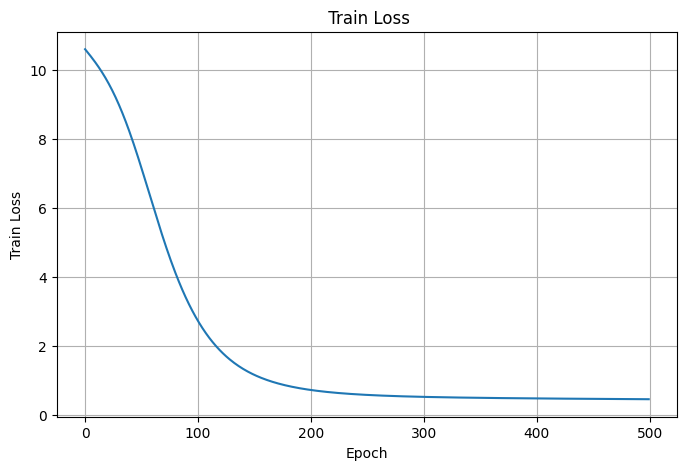

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title(' Train Loss')
plt.grid(True)
plt.show()
